In [12]:
import os
import datetime
import json
from dotenv import load_dotenv
from typing import TypedDict, List, Dict, Any, Literal
from langgraph.graph import StateGraph, START, END
from langchain_ollama import ChatOllama
from langchain_core.messages import HumanMessage
from langchain_community.tools import DuckDuckGoSearchRun
from IPython.display import Image, display, Markdown, HTML

load_dotenv()

# Inizializza il modello Ollama locale. Assicurati che Ollama sia in esecuzione 
# e di aver scaricato il modello desiderato (es. 'ollama run llama3')
llm = ChatOllama(model="llama3", temperature=0.5)

ddg_search = DuckDuckGoSearchRun()

KG_FILE = "knowledge_graph.json"

def load_kg() -> dict:
    if os.path.exists(KG_FILE):
        with open(KG_FILE, "r", encoding="utf-8") as f:
            return json.load(f)
    return {"nodes": [], "edges": []}

def save_kg(kg_data: dict):
    with open(KG_FILE, "w", encoding="utf-8") as f:
        json.dump(kg_data, f, indent=4)

# ==========================================
# 1. DEFINIZIONE DELLO STATO 
# ==========================================
class AgentState(TypedDict):
    user_request: str
    kg_context: Dict[str, Any]
    planned_topics: List[str]
    current_topic: str
    raw_resources: List[Dict[str, str]]
    verified_resources: List[Dict[str, str]]
    draft: str
    human_feedback: str
    status: str
    revision_count: int
    rejected_topics: List[str]

In [16]:
# ==========================================
# 2. DEFINIZIONE DEI NODI (AGENTI)
# ==========================================
from langchain_core.tools import tool
from langgraph.prebuilt import create_react_agent

def topic_planner(state: AgentState) -> dict:
    print("-> Esecuzione Topic Planner...")
    
    kg = state.get("kg_context", {"nodes": [], "edges": []})
    past_topics = [node["id"] for node in kg.get("nodes", []) if node.get("type") == "Topic"]
    rejected_topics = state.get("rejected_topics", [])
    
    all_avoids = past_topics + rejected_topics
    
    print(f"   [KG] Argomenti passati trovati: {past_topics}")
    if rejected_topics:
        print(f"   [Feedback] Argomenti scartati in questa sessione: {rejected_topics}")
    
    prompt = f"La richiesta dell'utente è: '{state['user_request']}'. Abbiamo GIÀ scritto articoli o scartato questi argomenti: {all_avoids}. Devi scegliere argomenti COMPLETAMENTE DIVERSI e molto specifici riguardo notizie sportive RECENTI o gli ultimi eventi. Fornisci esattamente 2 nuovi argomenti interessanti separati da virgola. Rispondi SOLO con gli argomenti, nessun altro testo."
    try:
        response = llm.invoke([HumanMessage(content=prompt)]).content
        planned = [t.strip() for t in response.split(",")] if "," in response else [response.strip()]
    except Exception as e:
        print(f"   [Errore LLM in Planner] {e}")
        planned = ["Default Topic 1", "Default Topic 2"]
        
    print(f"   [LLM] Argomenti pianificati: {planned}")
    return {"planned_topics": planned, "current_topic": planned[0], "status": "planning_done"}

@tool
def cerca_sul_web(query: str) -> str:
    """Cerca sul web le ultime notizie e informazioni aggiornate."""
    return ddg_search.invoke(query)

def resource_researcher(state: AgentState) -> dict:
    topic = state['current_topic']
    print(f"-> Esecuzione Resource Researcher (con paradigma ReAct) per: {topic}")
    
    # Crea un sub-agente ReAct per occuparsi della ricerca e del ragionamento
    tools = [cerca_sul_web]
    react_agent = create_react_agent(llm, tools)
    
    prompt = f"Sei un assistente di ricerca. Devi trovare informazioni recenti e dettagliate su questo argomento sportivo: '{topic}'. Ragiona passo passo. Usa il tool 'cerca_sul_web' tante volte quanto necessario per trovare informazioni rilevanti e complete. Al termine, scrivi un post dettagliato e in italiano dei fatti trovati."
    
    try:
        # L'agente ReAct eseguirà il ciclo Thought -> Action -> Observation iterativamente
        response = react_agent.invoke({"messages": [("user", prompt)]})
        # L'ultimo messaggio dell'agente rappresenta la sua conclusione dopo aver ragionato e cercato
        final_answer = response["messages"][-1].content
    except Exception as e:
        print(f"   [Errore ReAct Agent] {e}")
        final_answer = ddg_search.invoke(topic)
        
    raw = [{"url": f"Agent Research: {topic}", "content": final_answer}]
        
    return {"raw_resources": raw, "status": "research_done"}

def quality_fact_checker(state: AgentState) -> dict:
    print("-> Esecuzione Quality & Fact Checker...")
    raw = state.get("raw_resources", [])
    topic = state["current_topic"]
    verified = []
    
    for res in raw:
        content = res.get('content', '')[:1500]
        prompt = f"Argomento: '{topic}'.\n\nFrammento di contenuto: '{content}'.\n\nQuesto contenuto è utile e pertinente per scrivere un articolo di blog sull'argomento? Rispondi esattamente 'SI' o 'NO'."
        try:
            eval_res = llm.invoke([HumanMessage(content=prompt)]).content.upper()
            if "SI" in eval_res or "SÌ" in eval_res:
                verified.append(res)
                print("   [LLM Evaluator] Fonte approvata.")
            else:
                print(f"   [LLM Evaluator] Fonte scartata. Risposta: {eval_res}")
        except Exception as e:
            print(f"   [LLM Evaluator Error] Errore API, accetto la fonte per default. Dettaglio: {e}")
            verified.append(res)
            
    return {"verified_resources": verified, "status": "fact_checking_done"}

def drafter(state: AgentState) -> dict:

    print("-> Esecuzione Drafter (Generazione testo in corso)...")
    
    feedback = state.get("human_feedback", "")
    previous_draft = state.get("draft", "")  
    sources = state.get("verified_resources", [])
    topic = state['current_topic']
    
    sources_text = "\n".join([s.get("content", "")[:1000] for s in sources])
    
    prompt = f"Scrivi un breve e coinvolgente articolo di blog sulle ultime notizie riguardo '{topic}'. Usa questi frammenti di ricerca (frutto delle indagini dell'agente) come contesto primario:\n{sources_text}\n\nIMPORTANTE: Inizia la tua risposta con 'TITOLO: <il tuo titolo accattivante>' sulla primissima riga, seguito dal contenuto dell'articolo. L'articolo deve essere in italiano."
    
    if feedback and previous_draft:
        prompt += f"\n\nEcco la tua BOZZA PRECEDENTE:\n---\n{previous_draft}\n---\n\nCRITICO: L'utente ha rifiutato la bozza precedente con questo feedback: '{feedback}'. DEVI riscrivere pesantemente la bozza per incorporare questo feedback. Se il feedback chiede di cambiare sport o argomento, IGNORA IMMEDIATAMENTE i vecchi frammenti e inventa un nuovo articolo basato puramente sul nuovo argomento richiesto. Fornisci un NUOVO TITOLO come richiesto."
        
    try:
        response_text = llm.invoke([HumanMessage(content=prompt)]).content
    except Exception as e:
        print(f"\n[ERRORE FATALE] Impossibile generare la bozza. Dettaglio errore: {e}")
        # Rimossa la terminazione silenziosa (SystemExit) per poter leggere il traceback effettivo in caso di errore in Jupyter
        raise e
        
    new_title = topic
    draft = response_text
    
    lines = response_text.split('\n')
    for i, line in enumerate(lines):
        if line.strip().upper().startswith('TITOLO:'):
            new_title = line.split(':', 1)[1].strip().replace('**', '').replace('"', '').replace("'", "")
            draft = "\n".join(lines[:i] + lines[i+1:]).strip()
            break
        elif line.strip().upper().startswith('**TITOLO:**'):
            new_title = line.split(':', 1)[1].strip().replace('**', '').replace('"', '').replace("'", "")
            draft = "\n".join(lines[:i] + lines[i+1:]).strip()
            break

    return {"draft": draft, "current_topic": new_title, "status": "draft_ready", "revision_count": state.get("revision_count", 0) + 1}

def human_review(state: AgentState) -> dict:
    display(HTML("<hr><h2 style='color: orange;'>🛑 HUMAN IN THE LOOP 🛑</h2>"))
    display(Markdown(f"### Bozza attuale da revisionare:\n\n{state.get('draft')}"))
    display(HTML("<hr>"))
    
    user_input = input("Vuoi approvare la bozza? (y/n) o fornisci feedback per riscriverla: ").strip()
    
    if user_input.lower() in ['y', 'yes', 'si']:
        return {"status": "approved", "human_feedback": ""}
    elif user_input.lower() in ['n', 'no']:
        rejected = state.get("rejected_topics", []) + [state["current_topic"]]
        return {"status": "rejected_topic", "human_feedback": "Notizia scartata dall'utente.", "rejected_topics": rejected}
    else:
        return {"status": "rewrite", "human_feedback": user_input}

def kg_updater(state: AgentState) -> dict:
    print("-> Esecuzione KG Updater & Web Publisher...")
    topic = state["current_topic"]
    kg = state.get("kg_context", {"nodes": [], "edges": []})
    
    import copy
    new_kg = copy.deepcopy(kg)
    
    if not any(n["id"] == topic for n in new_kg.setdefault("nodes", [])):
        new_kg["nodes"].append({"id": topic, "type": "Topic"})
    
    post_id = f"Post_{len(new_kg['nodes'])}"
    new_kg["nodes"].append({"id": post_id, "type": "Post", "content": state["draft"]}) 
    new_kg.setdefault("edges", []).append({"source": post_id, "target": topic, "relation": "COVERS_TOPIC"})
    
    print(f"   [KG] Nodo '{topic}' aggiunto. Nodi totali: {len(new_kg['nodes'])}")
    
    save_kg(new_kg) 
    
    html_path = "index.html"
    if os.path.exists(html_path):
        with open(html_path, "r", encoding="utf-8") as f:
            html_content = f.read()
            
        date_str = datetime.datetime.now().strftime("%d/%m/%Y %H:%M")
        formatted_draft = state["draft"].replace('\n', '<br>')
        
        new_post_html = f'''
        <article class="post-card">
            <h2 class="post-title">{topic}</h2>
            <div class="post-meta">Pubblicato il {date_str}</div>
            <div class="post-content">
                {formatted_draft}
            </div>
            <div class="post-tags">
                <span class="tag">AI Generated</span>
                <span class="tag">Sport News</span>
            </div>
        </article>
        <!-- NEW_POSTS_HERE -->'''
        
        html_content = html_content.replace("<!-- NEW_POSTS_HERE -->", new_post_html)
        with open(html_path, "w", encoding="utf-8") as f:
            f.write(html_content)
        print("   [Web Publisher] Post aggiunto al file index.html!")
    
    return {"status": "kg_updated", "kg_context": new_kg}

=== GENERAZIONE DEL GRAFO IN CORSO ===


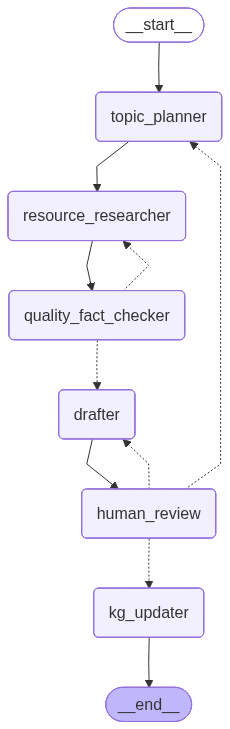

In [17]:
# ==========================================
# 3. DEFINIZIONE DEGLI ARCHI E COMPILAZIONE GRAFO
# ==========================================

def check_resources_quality(state: AgentState) -> Literal["drafter", "resource_researcher"]:
    if len(state.get("verified_resources", [])) > 0:
        return "drafter"
    return "resource_researcher"

def check_approval(state: AgentState) -> Literal["kg_updater", "drafter", "topic_planner"]:
    if state["status"] == "approved":
        return "kg_updater"
    elif state["status"] == "rejected_topic":
        return "topic_planner"
    else:
        return "drafter"


workflow = StateGraph(AgentState)

workflow.add_node("topic_planner", topic_planner)
workflow.add_node("resource_researcher", resource_researcher)
workflow.add_node("quality_fact_checker", quality_fact_checker)
workflow.add_node("drafter", drafter)
workflow.add_node("human_review", human_review)
workflow.add_node("kg_updater", kg_updater)

workflow.add_edge(START, "topic_planner")
workflow.add_edge("topic_planner", "resource_researcher")
workflow.add_edge("resource_researcher", "quality_fact_checker")
workflow.add_conditional_edges("quality_fact_checker", check_resources_quality, {"drafter": "drafter", "resource_researcher": "resource_researcher"})
workflow.add_edge("drafter", "human_review")
workflow.add_conditional_edges("human_review", check_approval, {"kg_updater": "kg_updater", "drafter": "drafter", "topic_planner": "topic_planner"})
workflow.add_edge("kg_updater", END)

app = workflow.compile()

print("=== GENERAZIONE DEL GRAFO IN CORSO ===")
try:
    img = app.get_graph().draw_mermaid_png()
    display(Image(img))
    with open("graph.png", "wb") as f:
        f.write(img)
except Exception as e:
    print("Errore nella generazione dell'immagine:", e)
print("======================================\n")

In [18]:
# ==========================================
# 4. ESECUZIONE (TEST DELLA PIPE LANGGRAPH)
# ==========================================
print("=== INIZIO PROCESSO LANGGRAPH ===")

persisted_kg = load_kg()

initial_state = {
    "user_request": "Ultimi aggiornamenti, notizie e cronaca riguardanti il mondo dello sport (calcio, tennis, motori, basket, ecc.).",
    "kg_context": persisted_kg,
    "planned_topics": [],
    "current_topic": "",
    "raw_resources": [],
    "verified_resources": [],
    "draft": "",
    "human_feedback": "",
    "status": "start",
    "revision_count": 0,
    "rejected_topics": []
}

for output in app.stream(initial_state):
    pass
print("\n=== PROCESSO CONCLUSO ===")

=== INIZIO PROCESSO LANGGRAPH ===
-> Esecuzione Topic Planner...
   [KG] Argomenti passati trovati: ['Gare di canottaggio a livello olimpico', 'Ciclismo su strada femminile', 'Gliding to Glory: The Thrilling World of International Speed Skating', 'La NBA sbarca sullAcqua: LEmozione del Nuoto incontra la Competizione della Lega', 'La Magia del Bowling: UnEsperienza Unica e Divertente', 'La Nuova Era del Tennis: Le Grandi Aspettative per il Roland Garros 2026', 'Il Re della NBA: LeBron James Continua a Stupire il Mondo', 'La Corsia Dei Campioni: Verstappen Affronta La Sfida Per Il Titolo 2026', 'La Vittoria dellInter nella Champions League 2026: Un Nuovo Capitolo nella Storia Nerazzurra', 'Le Ultime Novità sulla Formula E 2026: Una Stagione Elettrizzante in Corso', 'La Maratona di Boston 2024: UnEdizione Storica con Nuovi Record e Partecipazione Record']
   [Errore LLM in Planner] model 'llama3' not found (status code: 404)
   [LLM] Argomenti pianificati: ['Default Topic 1', 'Default Top

C:\Users\xolor\AppData\Local\Temp\ipykernel_18564\1811585125.py:42: LangGraphDeprecatedSinceV10: create_react_agent has been moved to `langchain.agents`. Please update your import to `from langchain.agents import create_agent`. Deprecated in LangGraph V1.0 to be removed in V2.0.
  react_agent = create_react_agent(llm, tools)


-> Esecuzione Quality & Fact Checker...
   [LLM Evaluator Error] Errore API, accetto la fonte per default. Dettaglio: model 'llama3' not found (status code: 404)
-> Esecuzione Drafter (Generazione testo in corso)...

[ERRORE FATALE] Impossibile generare la bozza. Dettaglio errore: model 'llama3' not found (status code: 404)


ResponseError: model 'llama3' not found (status code: 404)